# Import libraries

In [1]:
import os
import warnings

import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.cm as cm

import seaborn as sns

from scipy.signal import find_peaks

In [2]:
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', 50)

In [3]:
sns.set_theme()

mpl.rcParams.update({
    "font.family": ["Comic Sans MS", "DejaVu Sans", "Arial"],
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [4]:
path_to_save = './../results/02b_add_analysis'

# Loading data

## Mass ratios

In [5]:
path_to_data= './../data/additional_data/mass_ratios/fractions_mass_ratios.xlsx'

In [6]:
data_mass = pd.read_excel(path_to_data)

print(data_mass.shape)
data_mass

(8, 3)


,Membrane_Type,"Mass, mg","Ratio, %"
0,<70,13.0,1.868353
1,<25,26.7,3.837310
2,<5,623.5,89.609083
3,<3,4.0,0.574878
4,<2.5,5.7,0.819201
5,<2,5.3,0.761713
6,<0.4,6.7,0.962920
7,<0.2,10.9,1.566542


## FTIR spectra

In [7]:
path_to_data = './../data/additional_data/ftir_sulfate/'

### $K_2SO_4$

In [8]:
data_k2so4 = pd.read_csv(f'{path_to_data}/K2SO4.dpt', sep=",", header=None, names=['wavenumber', 'absorbance'])

print(data_k2so4.shape)
data_k2so4.head(3)

(3733, 2)


,wavenumber,absorbance
0,3998.31069,0.00458
1,3997.34631,0.00458
2,3996.38194,0.00458


### $MnSO_4$

In [9]:
data_mnso4 = pd.read_csv(f'{path_to_data}/MnSO4.dpt', sep=",", header=None, names=['wavenumber', 'absorbance'])

print(data_mnso4.shape)
data_mnso4.head(3)

(3733, 2)


,wavenumber,absorbance
0,3998.31069,0.00339
1,3997.34631,0.00339
2,3996.38194,0.00339


# Fractions distribution by mass

## Data wrangling

### Column names correction

In [10]:
columns_dict = {
    'Membrane_Type': 'membrane',
    'Mass, mg': 'mass',
    'Ratio, %': 'ratio'
}

In [11]:
data_mass = data_mass.rename(columns=columns_dict)

print(data_mass.shape)
data_mass.head(3)

(8, 3)


,membrane,mass,ratio
0,<70,13.0,1.868353
1,<25,26.7,3.837310
2,<5,623.5,89.609083


### Column values correction

In [12]:
data_mass['membrane'] = data_mass['membrane'].apply(lambda x: f'${x}$')
data_mass['mass'] = data_mass['mass'].apply(lambda x: round(x, 2))
data_mass['ratio'] = data_mass['ratio'].apply(lambda x: round(x, 2))

print(data_mass.shape)
data_mass.head(3)

(8, 3)


,membrane,mass,ratio
0,$<70$,13.0,1.87
1,$<25$,26.7,3.84
2,$<5$,623.5,89.61


## Histogram visualization

In [13]:
fontsize = 16

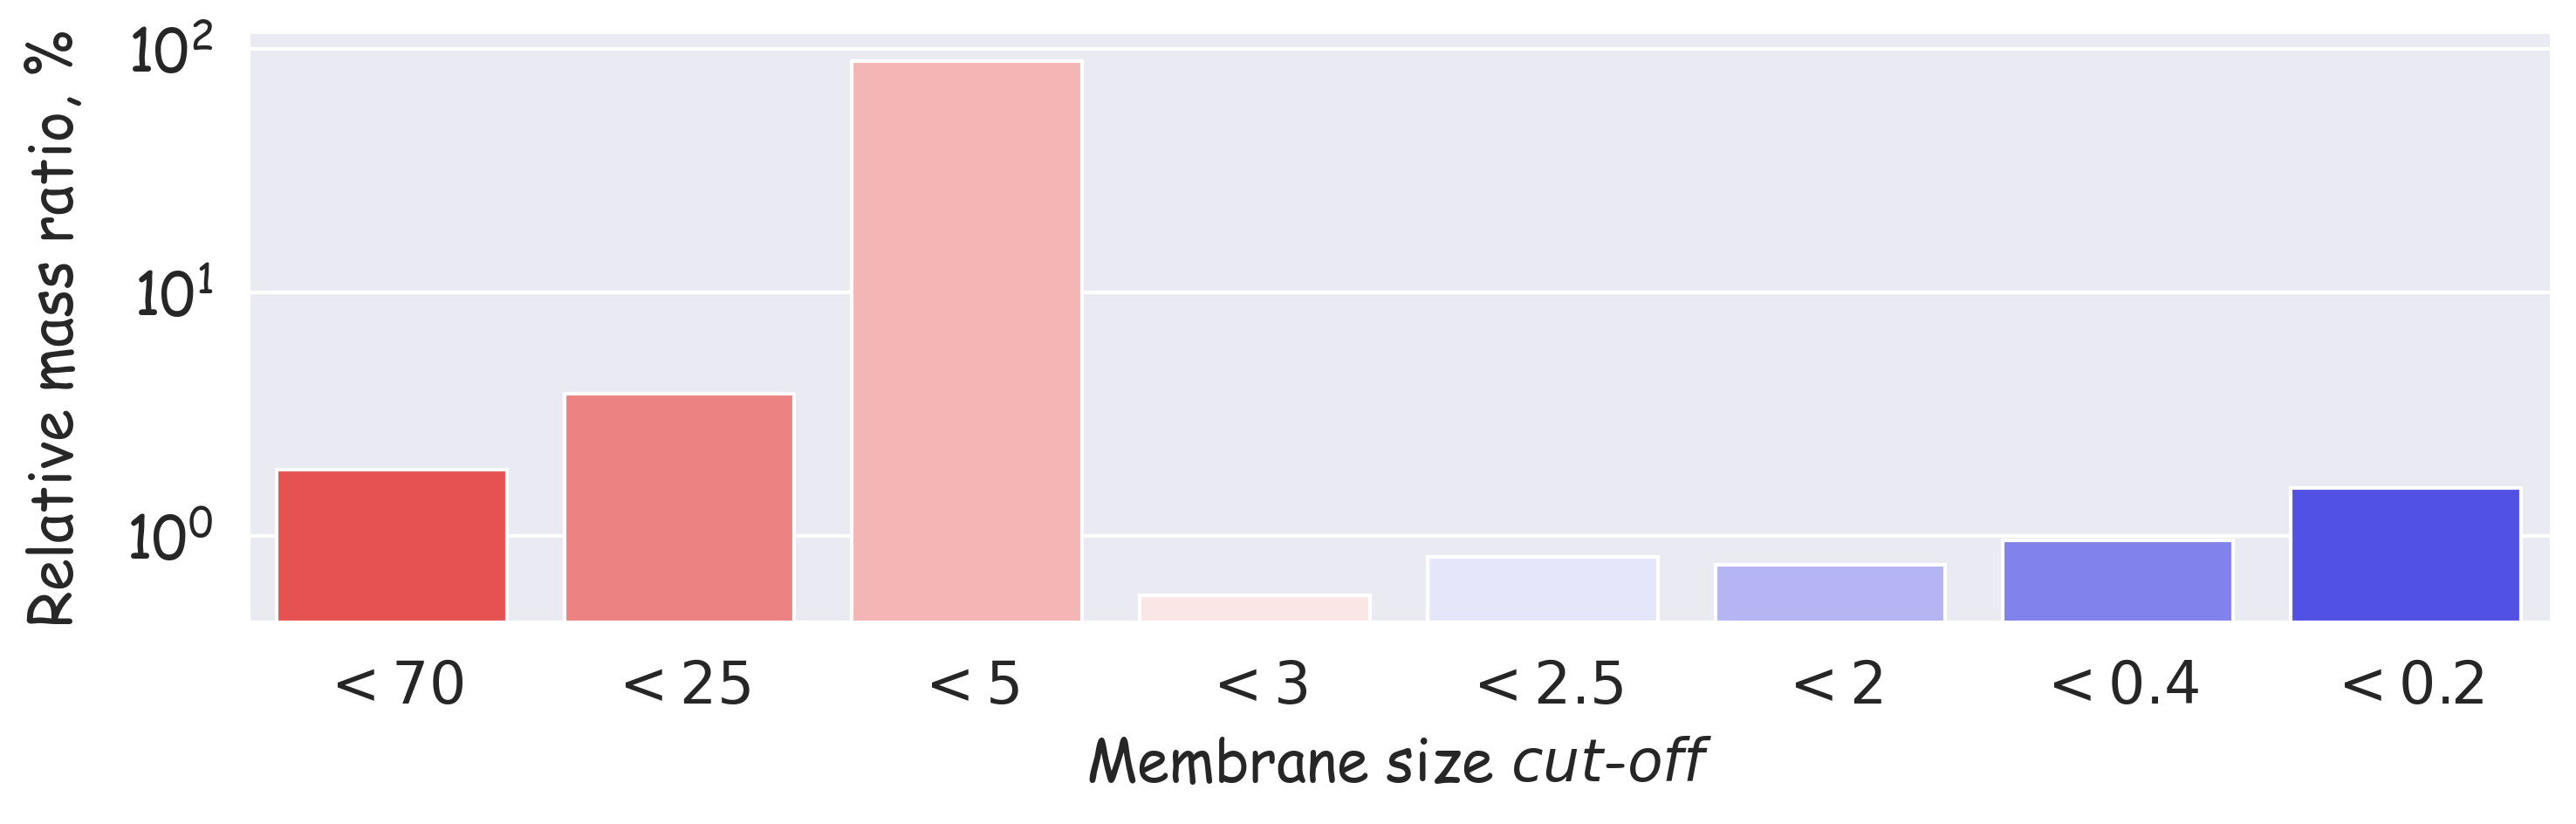

In [14]:
fig, ax = plt.subplots(figsize=(10, 3.3), dpi=300)

sns.barplot(
    data=data_mass,
    x='membrane',
    y='ratio',
    palette='bwr_r',
    ax=ax
)

ax.set_xlabel('Membrane size $cut$-$off$', fontsize=fontsize)
ax.set_ylabel('Relative mass ratio, %', fontsize=fontsize, labelpad=10)

ax.tick_params(axis='x', labelsize=fontsize)
ax.tick_params(axis='y', labelsize=fontsize)

ax.set_yscale('log', base=10)

plt.tight_layout()

plt.savefig(f'{path_to_save}/mass_fractions_barplot.png', dpi=600)

plt.show()

# Sulfate FTIR spectra

## Data wrangling

In [15]:
wavenumber_k2so4 = data_k2so4['wavenumber'].values
spectrum_k2so4 = data_k2so4['absorbance'].values

In [16]:
wavenumber_mnso4 = data_mnso4['wavenumber'].values
spectrum_mnso4 = data_mnso4['absorbance'].values

### Selection of main specral components

In [17]:
fingerprint_mask_k2so4 = (wavenumber_k2so4 <= 1900) & (wavenumber_k2so4 >= 400)

wavenumber_k2so4_fpr = wavenumber_k2so4[fingerprint_mask_k2so4]
spectrum_k2so4_fpr = spectrum_k2so4[fingerprint_mask_k2so4]

In [18]:
fingerprint_mask_mnso4 = (wavenumber_mnso4 <= 1900) & (wavenumber_mnso4 >= 400)

wavenumber_mnso4_fpr = wavenumber_mnso4[fingerprint_mask_mnso4]
spectrum_mnso4_fpr = spectrum_mnso4[fingerprint_mask_mnso4]

### Scaling to range [0...1] (*MinMax*)

In [19]:
spectrum_k2so4_fpr_normalized = (spectrum_k2so4_fpr- np.min(spectrum_k2so4_fpr)) / (np.max(spectrum_k2so4_fpr) - np.min(spectrum_k2so4_fpr))

In [20]:
spectrum_mnso4_fpr_normalized = (spectrum_mnso4_fpr - np.min(spectrum_mnso4_fpr)) / (np.max(spectrum_mnso4_fpr) - np.min(spectrum_mnso4_fpr))

# Spectra visualization

## Base variables

In [21]:
FONT_SIZE_TITLE = 16

FONT_SIZE_XLABEL = 16
FONT_SIZE_YLABEL = 16

FONT_SIZE_XTICKS = 14
FONT_SIZE_YTICKS = 14

## Peaks analysis

In [22]:
def find_spectrum_peaks(wavenumber, spectrum, prominence=0.03, height=0.05, width=10):
    peaks, properties = find_peaks(
        spectrum,
        prominence=prominence,
        height=height,
        width=width
    )
    
    peak_positions = wavenumber[peaks]
    peak_intensities = spectrum[peaks]
    
    return peak_positions, peak_intensities, properties

In [23]:
peaks_k2so4, intensities_k2so4, _ = find_spectrum_peaks(
    wavenumber_k2so4_fpr,
    spectrum_k2so4_fpr_normalized,
    prominence=0.03,
    height=0.05,
    width=5
)

In [24]:
peaks_mnso4, intensities_mnso4, _ = find_spectrum_peaks(
    wavenumber_mnso4_fpr,
    spectrum_mnso4_fpr_normalized,
    prominence=0.03,
    height=0.05,
    width=5
)

## Visualization

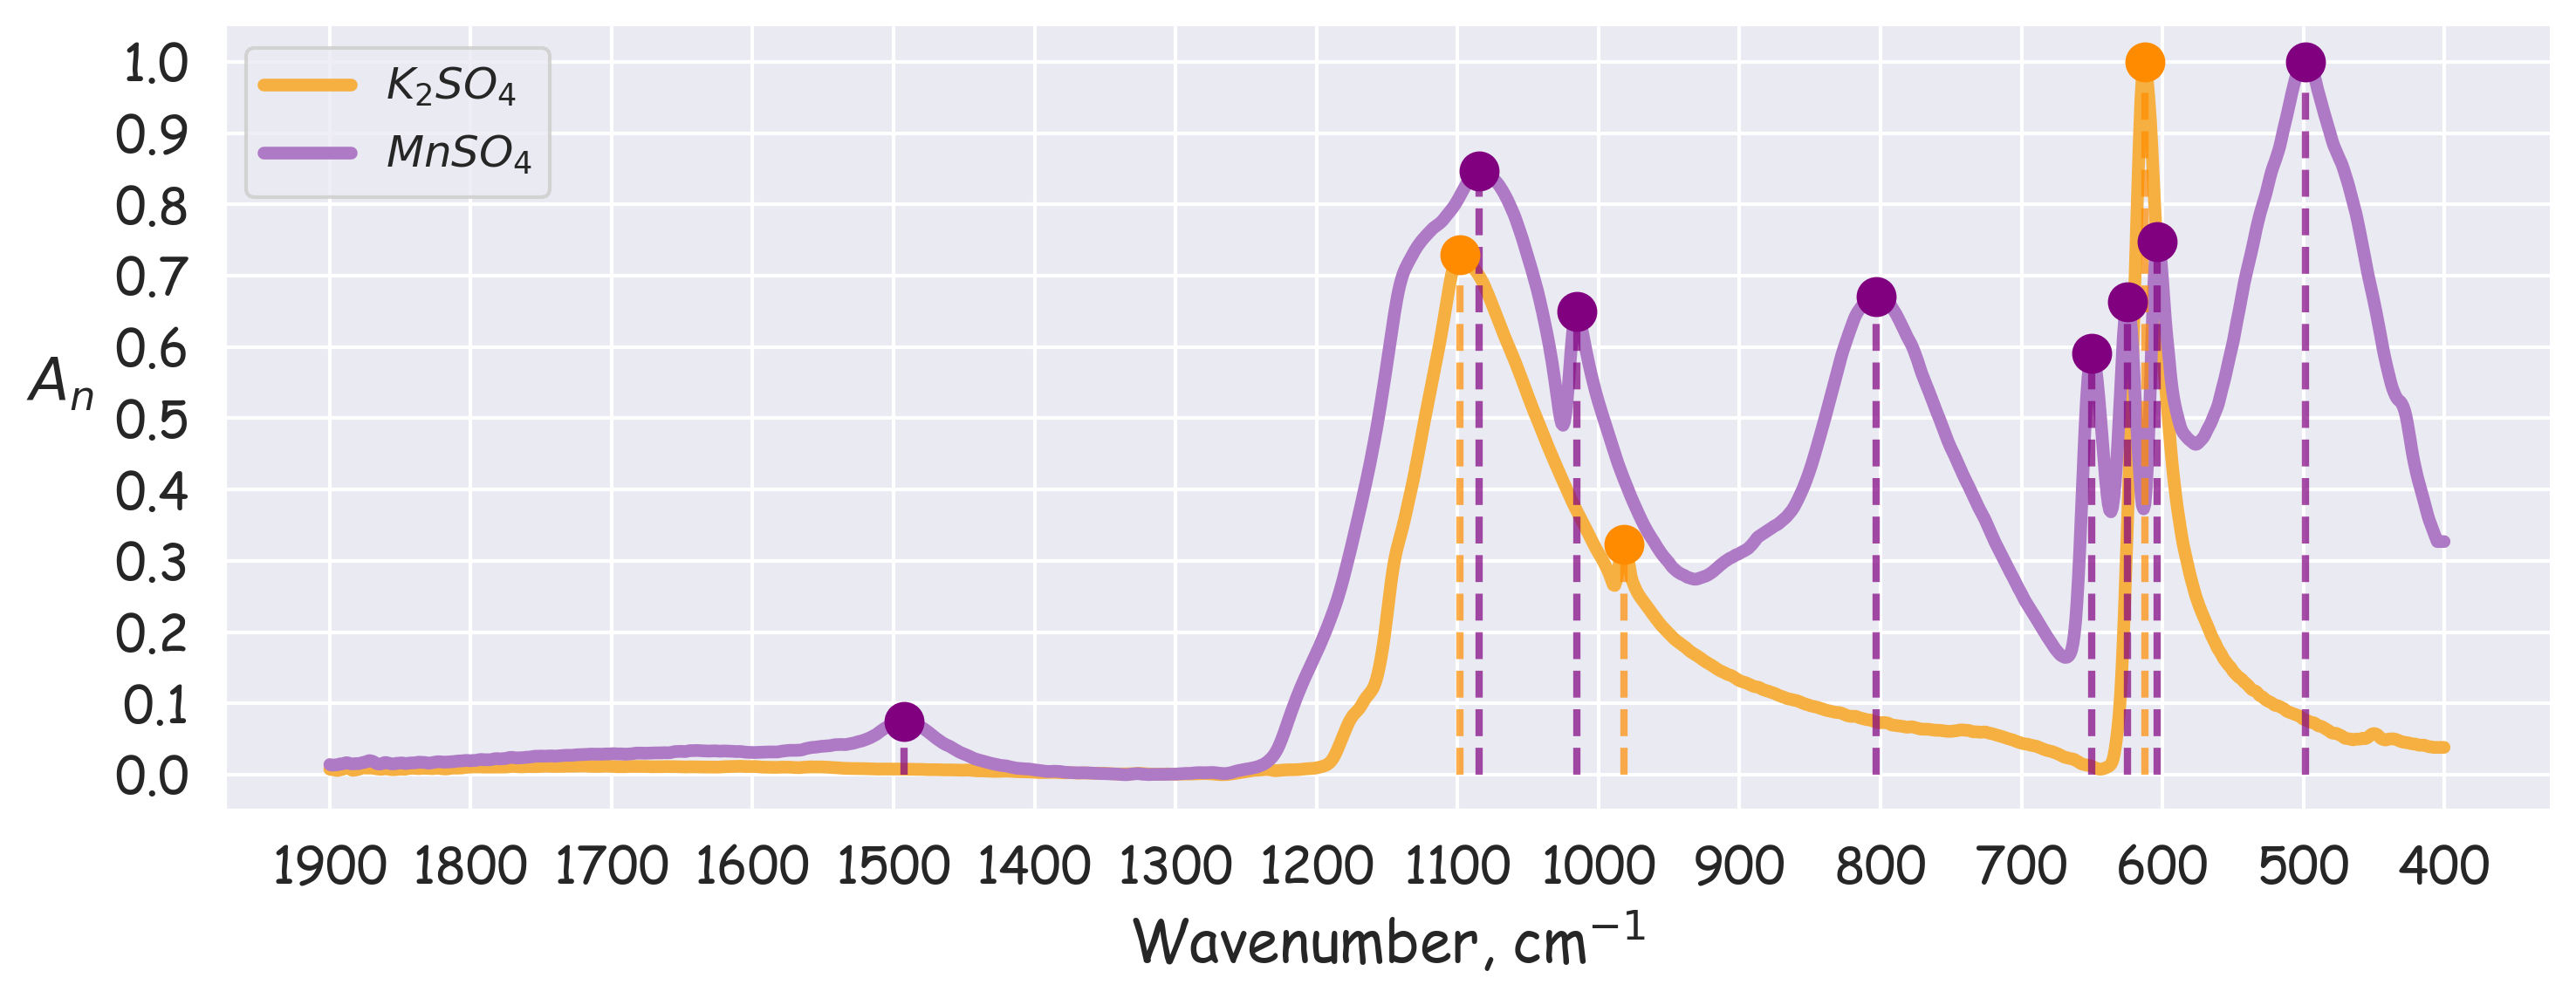

In [25]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4), dpi=300)

ax.plot(wavenumber_k2so4_fpr, spectrum_k2so4_fpr_normalized, label='$K_2SO_4$', linewidth=3.5, color='#F5B041', alpha=1.0)
ax.plot(wavenumber_mnso4_fpr, spectrum_mnso4_fpr_normalized, label='$MnSO_4$', linewidth=3.5, color='#AF7AC5', alpha=1.0)

ax.scatter(peaks_k2so4, intensities_k2so4, color='darkorange', s=100, zorder=3)
ax.scatter(peaks_mnso4, intensities_mnso4, color='purple', s=100, zorder=3)

for peak, intensity in zip(peaks_k2so4, intensities_k2so4):
    ax.vlines(x=peak, ymin=0, ymax=intensity, color='darkorange', linestyle='--', linewidth=2, alpha=0.7)

for peak, intensity in zip(peaks_mnso4, intensities_mnso4):
    ax.vlines(x=peak, ymin=0, ymax=intensity, color='purple', linestyle='--', linewidth=2, alpha=0.7)

ax.set_xlabel('Wavenumber, cm$^{-1}$', fontsize=FONT_SIZE_XLABEL)
ax.set_ylabel('$A_n$', fontsize=FONT_SIZE_YLABEL, rotation=0, labelpad=15)

ax.tick_params(axis='x', labelsize=FONT_SIZE_XTICKS)
ax.tick_params(axis='y', labelsize=FONT_SIZE_YTICKS)
ax.xaxis.set_major_locator(ticker.MultipleLocator(100))
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.1))

ax.invert_xaxis()

ax.legend(loc='upper left', fontsize=12)

plt.tight_layout()
plt.savefig(f'{path_to_save}/sulfate_spectra.png', dpi=1800)
plt.show()